- 3 zhluky -> 5 zhlukov (prekryv);

In [23]:
from sklearn.decomposition import PCA
from helper_files.feature_selection_helper import *

# PCA

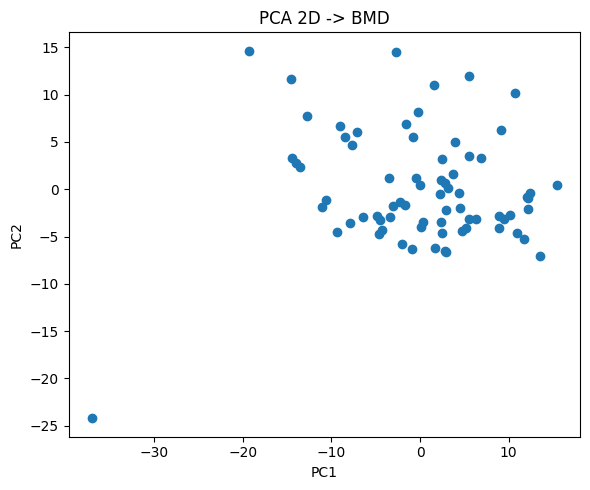

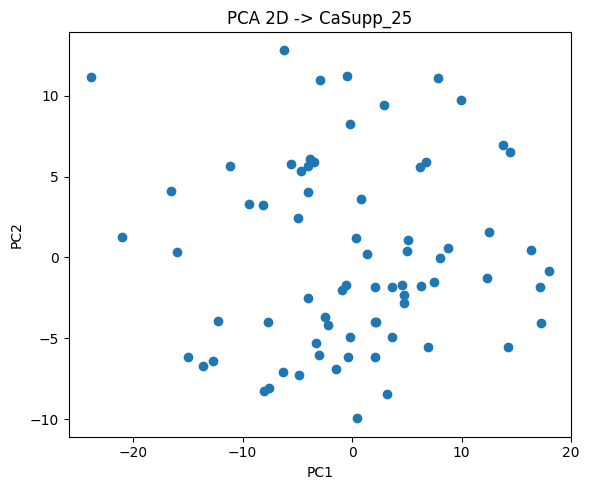

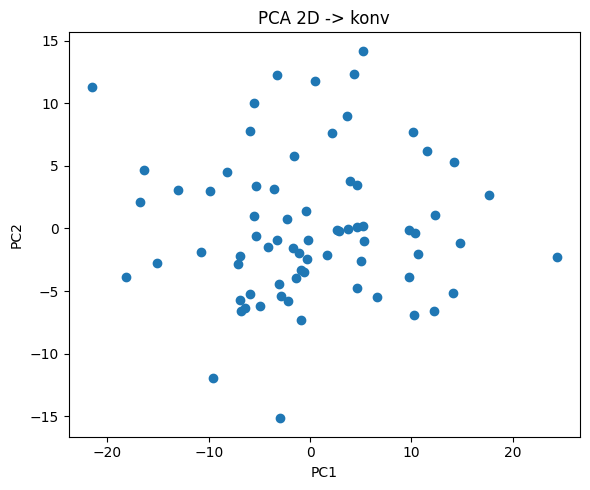

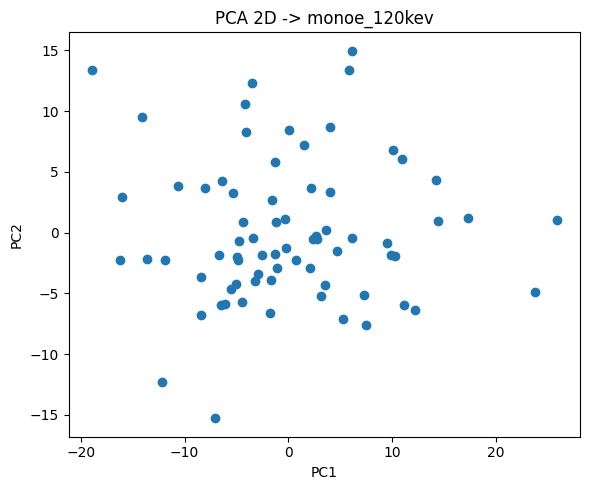

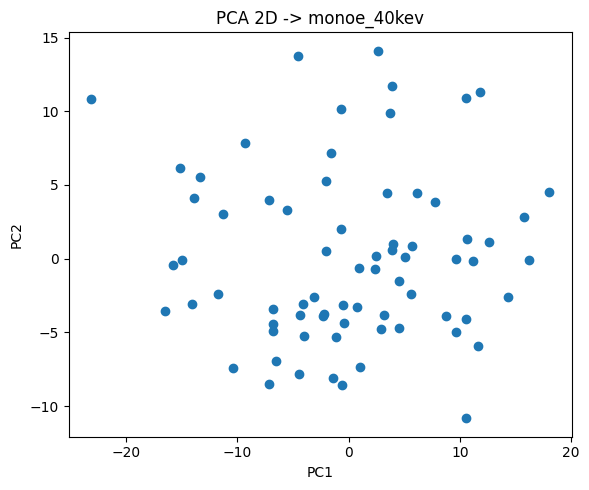

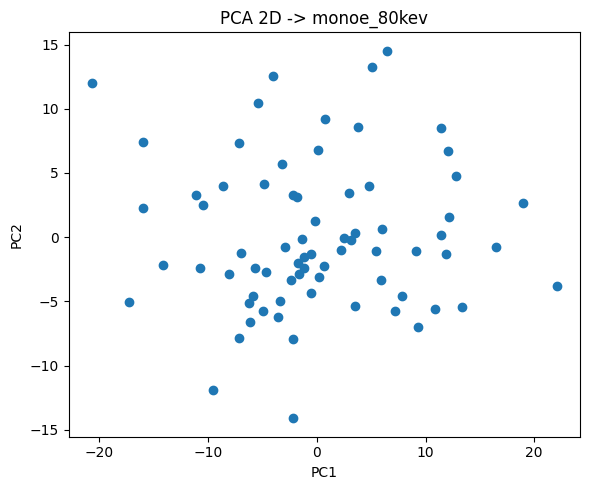

In [14]:
merged = merged_lesions_csv(r"E:\DATA_Myelomy")
for df_name, df in merged.items():
    df.drop(columns=['patient'], inplace=True)

    df_scaled = StandardScaler().fit_transform(df)

    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df_scaled)

    plt.figure(figsize=(6, 5))
    plt.scatter(df_pca[:, 0], df_pca[:, 1])
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA 2D -> {df_name}")
    plt.tight_layout()
    plt.show()

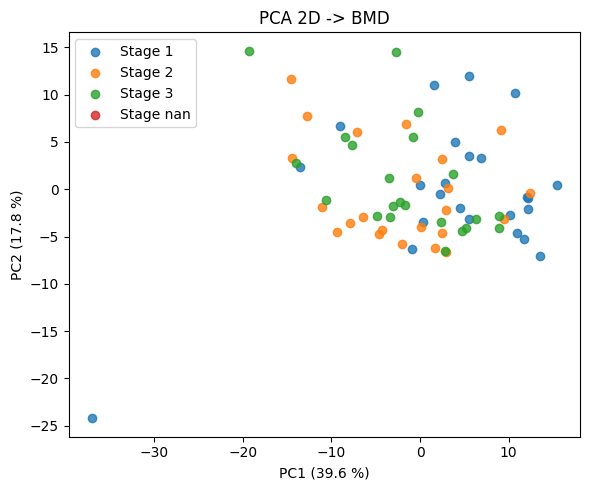

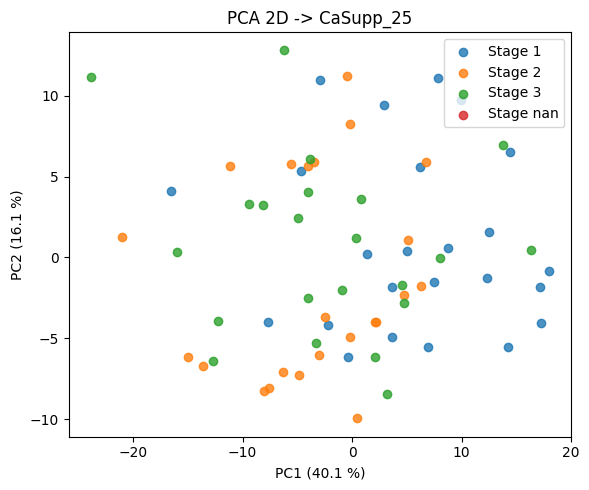

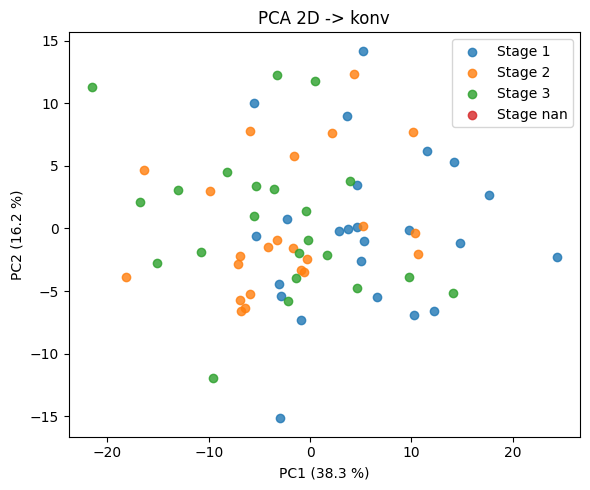

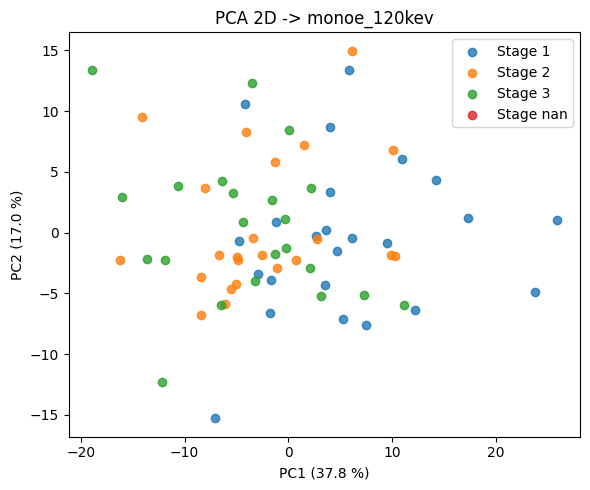

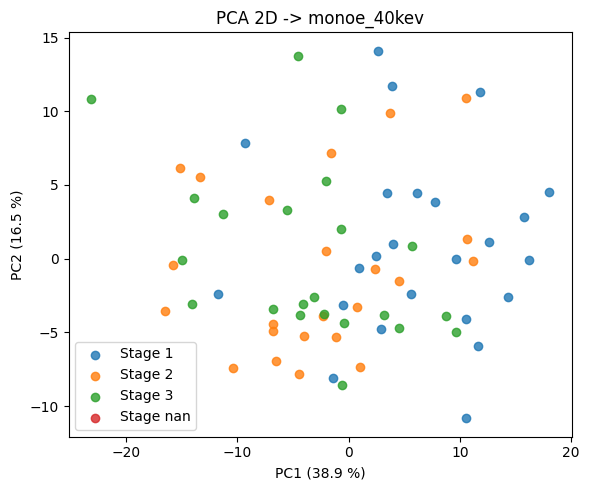

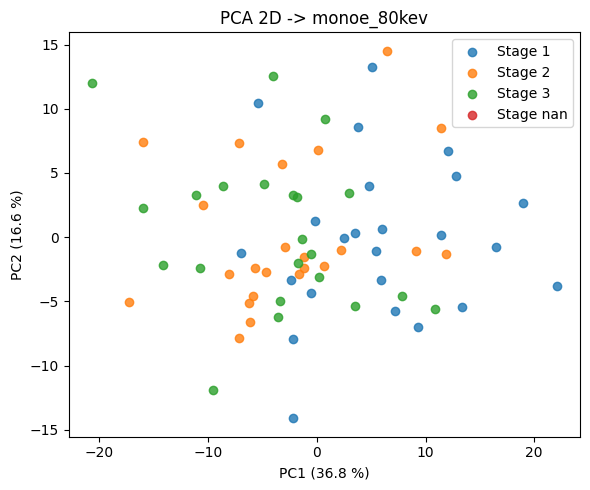

In [35]:
merged = merged_lesions_csv(r"E:\DATA_Myelomy")

clinical_df = df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

for df_name, df in merged.items():

    df_patient = df.copy()
    df_merged = df_patient.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')

    df_features = df_merged.drop(columns=['patient', 'Stage', 'Patient ID'])
    stage = df_merged['Stage']

    df_scaled = StandardScaler().fit_transform(df_features)

    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df_scaled)

    plt.figure(figsize=(6, 5))
    for s in sorted(stage.unique()):
        idx = stage == s
        plt.scatter(
            df_pca[idx, 0],
            df_pca[idx, 1],
            label=f"Stage {s}",
            alpha=0.8
        )
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
    plt.title(f"PCA 2D -> {df_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 2D clusters based on selected image features

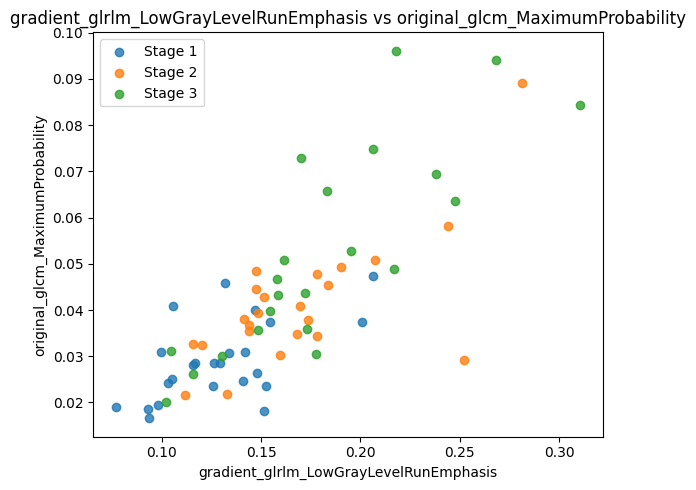

In [79]:
img_feature1 = 'gradient_glrlm_LowGrayLevelRunEmphasis'
img_feature2 = 'original_glcm_MaximumProbability'

df = pd.read_csv(r"E:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

df_merged = df.merge(clinical_df[['Patient ID', 'Stage']], left_on='patient', right_on='Patient ID', how='left')
df_merged = df_merged[df_merged['Stage'].notna()]
df_merged.drop(columns=['patient', 'Patient ID'], inplace=True)

plt.figure(figsize=(6,5))
for s in sorted(df_merged['Stage'].unique()):
    idx = df_merged['Stage'] == s
    plt.scatter(
        df_merged.loc[idx, img_feature1],
        df_merged.loc[idx, img_feature2],
        label=f"Stage {s}",
        alpha=0.8
    )

plt.xlabel(img_feature1)
plt.ylabel(img_feature2)
plt.title(f"{img_feature1} vs {img_feature2}")
plt.legend()
plt.tight_layout()
plt.show()

# 2D clusters based on selected clinical features

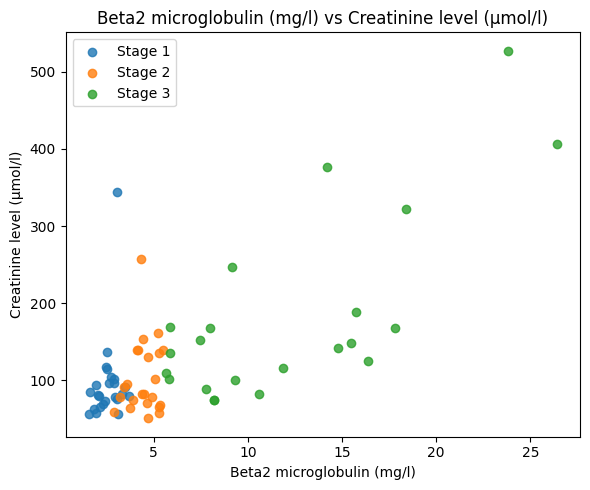

In [75]:
feature1 = 'Beta2 microglobulin (mg/l)'
feature2 = 'Creatinine level (µmol/l)'

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

clinical_df = clinical_df[clinical_df['Stage'].notna()]
clinical_df.drop(columns=['Patient ID'], inplace=True)

plt.figure(figsize=(6,5))
for s in sorted(clinical_df['Stage'].unique()):
    idx = clinical_df['Stage'] == s
    plt.scatter(
        clinical_df.loc[idx, feature1],
        clinical_df.loc[idx, feature2],
        label=f"Stage {s}",
        alpha=0.8
    )

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title(f"{feature1} vs {feature2}")
plt.legend()
plt.tight_layout()
plt.show()